# 🎯 用户行为轨迹 导购/推荐文本分析 — 分层高频词提取 (参考答案版)

## 业务背景
电商导购/推荐场景中，算法侧已为每条客询打好了**主题大类标签**（退货/退款/物流等）。
我们不需要用 LDA 盲猜主题，而是：
1. 全集统一跑 TF-IDF
2. 按已有的主题标签 GroupBy，提取每个主题下的高频痛点词
3. 结合 CSAT 评分做满意度分析

## 数据集
`ddosad/ecommerce-customer-service-satisfaction` — 85K 条电商导购/推荐记录，含 category / Sub-category / Customer Remarks / CSAT Score

---
## Step 0: 环境准备 & 数据导入

In [4]:
# 数据下载（首次运行取消注释）
# !kaggle datasets download ddosad/ecommerce-customer-service-satisfaction --path ./data --unzip

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
else:
    plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='muted')
print('✅ 环境配置完成！')

✅ 环境配置完成！


In [6]:
# 加载数据
df = pd.read_csv('./data/Customer_support_data.csv')
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(f'📊 数据集大小: {df.shape}')
print(f'📊 列名: {list(df.columns)}')
df.head(3)

📊 数据集大小: (85907, 20)
📊 列名: ['unique_id', 'channel_name', 'category', 'sub-category', 'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date', 'customer_city', 'product_category', 'item_price', 'connected_handling_time', 'agent_name', 'supervisor', 'manager', 'tenure_bucket', 'agent_shift', 'csat_score']


,unique_id,channel_name,category,sub-category,customer_remarks,order_id,order_date_time,issue_reported_at,issue_responded,survey_response_date,customer_city,product_category,item_price,connected_handling_time,agent_name,supervisor,manager,tenure_bucket,agent_shift,csat_score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5


---
## Step 1: 数据探索 & 理解业务语境

In [7]:
# 1.1 缺失值概览
print('=== 缺失值 ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\n有效文本占比: {df["customer_remarks"].notna().mean():.1%}')

=== 缺失值 ===
customer_remarks           57165
order_id                   18232
order_date_time            68693
customer_city              68828
product_category           68711
item_price                 68701
connected_handling_time    85665
dtype: int64

有效文本占比: 33.5%


=== 客询主题分布 ===
category
Returns               44097
Order Related         23215
Refund Related         4550
Product Queries        3692
Shopzilla Related      2792
Payments related       2327
Feedback               2294
Cancellation           2212
Offers & Cashback       480
Others                   99
App/website              84
Onboarding related       65
Name: count, dtype: int64


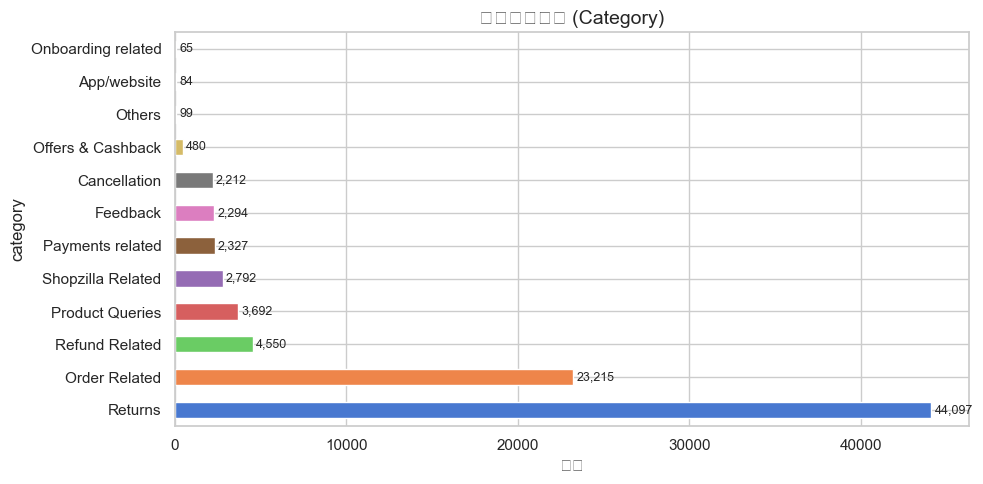

In [8]:
# 1.2 主题标签分布 (category)
cat_counts = df['category'].value_counts()
print('=== 客询主题分布 ===')
print(cat_counts)

fig, ax = plt.subplots(figsize=(10, 5))
cat_counts.plot(kind='barh', ax=ax, color=sns.color_palette('muted'))
ax.set_title('客询主题分布 (Category)', fontsize=14)
ax.set_xlabel('数量')
for i, v in enumerate(cat_counts.values):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

=== CSAT Score 分布 ===
csat_score
1    11230
2     1283
3     2558
4    11219
5    59617
Name: count, dtype: int64

差评占比 (CSAT <= 2): 14.6%


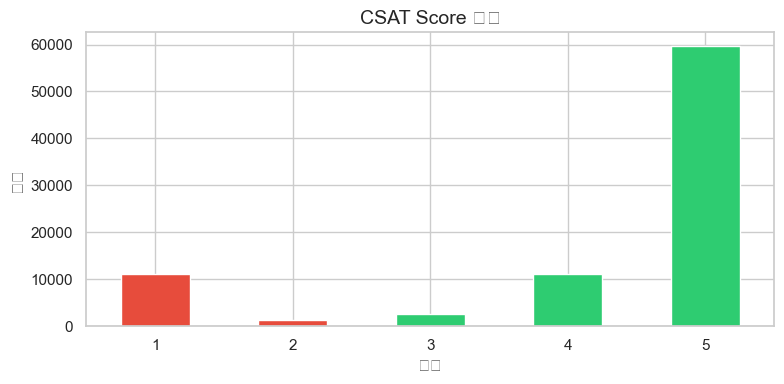

In [9]:
# 1.3 CSAT 评分分布 & 定义差评阈值
NEGATIVE_THRESHOLD = 2  # CSAT <= 2 视为不满意

csat_dist = df['csat_score'].value_counts().sort_index()
print('=== CSAT Score 分布 ===')
print(csat_dist)
print(f'\n差评占比 (CSAT <= {NEGATIVE_THRESHOLD}): {(df["csat_score"] <= NEGATIVE_THRESHOLD).mean():.1%}')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if x <= NEGATIVE_THRESHOLD else '#2ecc71' for x in csat_dist.index]
csat_dist.plot(kind='bar', ax=ax, color=colors)
ax.set_title('CSAT Score 分布', fontsize=14)
ax.set_xlabel('评分')
ax.set_ylabel('数量')
ax.set_xticklabels(csat_dist.index, rotation=0)
plt.tight_layout()
plt.show()

=== 各主题差评率 ===


,neg_rate,neg_count,total
category,,,
Others,0.333333,33,99
Cancellation,0.214738,475,2212
Product Queries,0.182557,674,3692
Order Related,0.178850,4152,23215
Feedback,0.168265,386,2294
Onboarding related,0.153846,10,65
Refund Related,0.150110,683,4550
Offers & Cashback,0.147917,71,480
Shopzilla Related,0.133238,372,2792


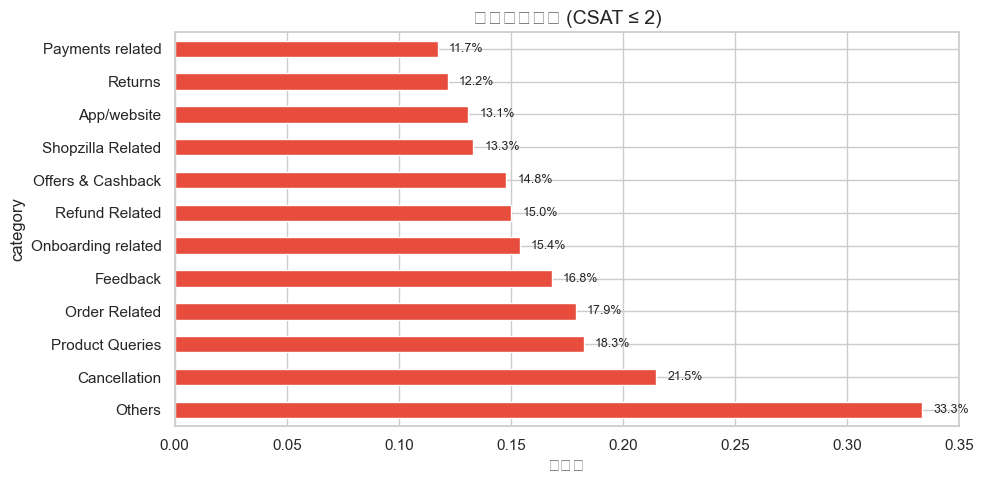

In [10]:
# 1.4 各主题的差评率对比
df['is_negative'] = (df['csat_score'] <= NEGATIVE_THRESHOLD).astype(int)

neg_rate_by_cat = (
    df.groupby('category')['is_negative']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'neg_rate', 'sum': 'neg_count', 'count': 'total'})
    .sort_values('neg_rate', ascending=False)
)
print('=== 各主题差评率 ===')
display(neg_rate_by_cat)

fig, ax = plt.subplots(figsize=(10, 5))
neg_rate_by_cat['neg_rate'].plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_title('各主题差评率 (CSAT ≤ 2)', fontsize=14)
ax.set_xlabel('差评率')
for i, v in enumerate(neg_rate_by_cat['neg_rate'].values):
    ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Step 2: 文本预处理

In [11]:
# 2.1 构建文本预处理管道
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# 业务自定义停用词（导购/推荐场景高频但无分析价值的词）
CUSTOM_STOPWORDS = {
    'order', 'product', 'item', 'please', 'thank',
    'customer', 'service', 'support', 'help', 'want',
    'need', 'get', 'got', 'would', 'could', 'also',
    'one', 'like', 'good', 'great', 'well', 'really',
}
stop_words = stop_words.union(CUSTOM_STOPWORDS)

def preprocess_text(text: str) -> str:
    """文本预处理管道: 小写 → 去标点 → 分词 → 去停用词 → 词形还原"""
    if pd.isna(text):
        return ''
    # 小写化
    text = text.lower()
    # 正则去噪: 只保留英文字母和空格
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # 分词
    tokens = word_tokenize(text)
    # 去停用词 + 词形还原 + 过滤短词
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token.isalpha() and token not in stop_words and len(token) > 2
    ]
    return ' '.join(tokens)

print('✅ 预处理函数定义完成')

✅ 预处理函数定义完成


In [12]:
# 2.2 批量预处理 + 过滤无文本行
df_text = df.dropna(subset=['customer_remarks']).copy()
print(f'有文本的记录: {len(df_text):,} / {len(df):,}')

df_text['clean_text'] = df_text['customer_remarks'].apply(preprocess_text)

# 过滤清洗后为空的行
df_text = df_text[df_text['clean_text'].str.strip() != ''].copy()
print(f'清洗后有效文本: {len(df_text):,}')
print(f'差评占比: {df_text["is_negative"].mean():.1%}')

df_text[['customer_remarks', 'clean_text', 'category', 'sub-category', 'csat_score']].head(5)

有文本的记录: 28,742 / 85,907
清洗后有效文本: 21,630
差评占比: 24.9%


,customer_remarks,clean_text,category,sub-category,csat_score
8,Shopzilla app and it's all coustomer care serv...,shopzilla app coustomer care service provided ...,Returns,Missing,5
11,Very bad,bad,Order Related,Delayed,1
17,Something,something,Order Related,Installation/demo,3
23,Godd job,godd job,Payments related,Payment related Queries,5
25,Issue not resolved pathetic service,issue resolved pathetic,Order Related,Order status enquiry,1


---
## Step 3: 全集统一 TF-IDF → 按主题标签 GroupBy 提取高频词

**核心流程**：
1. 在全部文本上统一跑一次 TF-IDF（保证 IDF 基准一致）
2. 按已有的 `category` 标签 GroupBy
3. 每个主题下取平均 TF-IDF 权重最高的词 → 即该主题的痛点关键词

In [13]:
# 3.1 全集统一跑 TF-IDF
TFIDF_MAX_FEATURES = 500
TFIDF_MIN_DF = 5
TFIDF_NGRAM_RANGE = (1, 2)  # 包含二元组捕捉短语

tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    min_df=TFIDF_MIN_DF,
    ngram_range=TFIDF_NGRAM_RANGE
)
X_tfidf = tfidf.fit_transform(df_text['clean_text'])

print(f'TF-IDF 矩阵形状: {X_tfidf.shape}')
print(f'词汇表大小: {len(tfidf.get_feature_names_out())}')

TF-IDF 矩阵形状: (21630, 500)
词汇表大小: 500


In [14]:
# 3.2 转成 DataFrame，附上主题标签列
df_tfidf = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out(),
    index=df_text.index
)
df_tfidf['category'] = df_text['category'].values

print(f'TF-IDF DataFrame 形状: {df_tfidf.shape}')
df_tfidf.head(3)

TF-IDF DataFrame 形状: (21630, 501)


,aap,able,account,achha,action,actually,add,address,agent,already,...,word,work,working,worst,worst experience,wrong,year,yes,yet,category
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Returns
11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Order Related
17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Order Related


In [15]:
# 3.3 按主题 GroupBy → 每个主题下取 Top 10 高权重词
TOP_N_KEYWORDS = 10

topic_keywords = df_tfidf.groupby('category').mean(numeric_only=True)

print('=' * 60)
print(f'📊 各主题 Top {TOP_N_KEYWORDS} 高频关键词')
print('=' * 60)

results = {}  # 存储各主题关键词供后续可视化
for topic in topic_keywords.index:
    top_words = topic_keywords.loc[topic].nlargest(TOP_N_KEYWORDS)
    results[topic] = top_words
    print(f'\n--- {topic} ---')
    print(top_words.to_string())

📊 各主题 Top 10 高频关键词

--- App/website ---
happy          0.140651
nice           0.125000
bad            0.095341
excellent      0.062500
getting        0.062500
nothing        0.062500
satisfied      0.062500
call           0.053848
feel           0.053177
performance    0.050528

--- Cancellation ---
thanks        0.066383
shopzilla     0.055161
nice          0.050821
delivery      0.048899
executive     0.029508
time          0.028429
happy         0.028111
bad           0.027525
problem       0.024459
experience    0.018740

--- Feedback ---
nice         0.070877
delivery     0.051398
excellent    0.037635
thanks       0.033488
shopzilla    0.026294
issue        0.026232
bad          0.023372
problem      0.022825
happy        0.022139
agent        0.020486

--- Offers & Cashback ---
nice          0.085917
excellent     0.041512
shopzilla     0.035930
person        0.033413
issue         0.032765
thanks        0.032367
happy         0.028327
behaviour     0.026224
experience    0.023

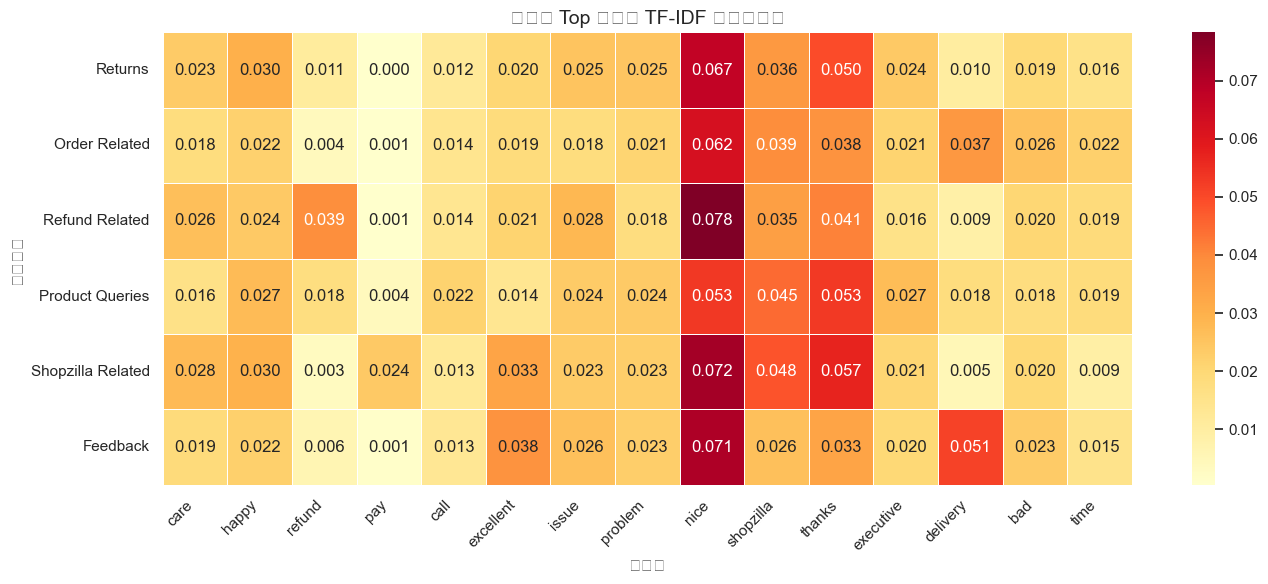

In [16]:
# 3.4 可视化：各主题 Top 关键词热力图
# 取量最大的 6 个主题
TOP_N_CATEGORIES = 6
HEATMAP_WORDS = 8

top_cats = df_text['category'].value_counts().nlargest(TOP_N_CATEGORIES).index.tolist()

# 收集每个主题的 Top 关键词（去重）
all_top_words = set()
for cat in top_cats:
    all_top_words.update(topic_keywords.loc[cat].nlargest(HEATMAP_WORDS).index.tolist())

# 构造热力图矩阵
heatmap_data = topic_keywords.loc[top_cats, list(all_top_words)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    ax=ax
)
ax.set_title('各主题 Top 关键词 TF-IDF 权重热力图', fontsize=14)
ax.set_ylabel('客询主题')
ax.set_xlabel('关键词')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Step 4: 差评 vs 好评 对比分析（按主题下钻）

In [17]:
# 4.1 对差评/好评分别做 GroupBy 聚合
df_tfidf['is_negative'] = df_text['is_negative'].values

# 选取量最大的主题进行对比
FOCUS_CATEGORY = 'Returns'
COMPARE_TOP_N = 10

mask_cat = df_tfidf['category'] == FOCUS_CATEGORY
mask_neg = df_tfidf['is_negative'] == 1
mask_pos = df_tfidf['is_negative'] == 0

# 取该主题下的词权重列（去掉标签列）
word_cols = tfidf.get_feature_names_out()

neg_avg = df_tfidf.loc[mask_cat & mask_neg, word_cols].mean()
pos_avg = df_tfidf.loc[mask_cat & mask_pos, word_cols].mean()

print(f'🔴 [{FOCUS_CATEGORY}] 差评 Top {COMPARE_TOP_N} 关键词:')
print(neg_avg.nlargest(COMPARE_TOP_N).to_string())
print(f'\n🟢 [{FOCUS_CATEGORY}] 好评 Top {COMPARE_TOP_N} 关键词:')
print(pos_avg.nlargest(COMPARE_TOP_N).to_string())

🔴 [Returns] 差评 Top 10 关键词:
bad           0.075470
shopzilla     0.057462
return        0.045715
issue         0.039406
poor          0.032193
problem       0.031845
worst         0.029597
time          0.023010
experience    0.021219
call          0.020083

🟢 [Returns] 好评 Top 10 关键词:
nice         0.083061
thanks       0.061855
happy        0.034455
shopzilla    0.030620
executive    0.025611
excellent    0.025106
care         0.025001
problem      0.023020
issue        0.021595
best         0.020206


⚠️ [Returns] 差评独有高权重词 (差评 - 好评 权重差):
bad               0.070762
poor              0.030177
return            0.029337
worst             0.028705
shopzilla         0.026842
issue             0.017812
pathetic          0.012313
resolved          0.011122
wrong             0.010704
received          0.010575
refund            0.010167
bad experience    0.009817
call              0.009817
experience        0.009183
time              0.009110


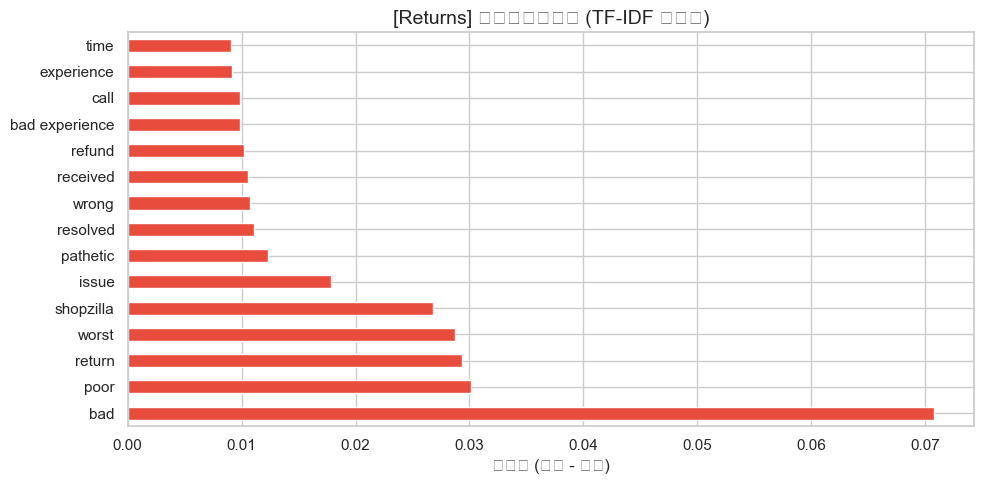

In [18]:
# 4.2 差评独有痛点词（差评权重 - 好评权重，差值最大的词）
diff = neg_avg - pos_avg
diff_top = diff.nlargest(15)

print(f'⚠️ [{FOCUS_CATEGORY}] 差评独有高权重词 (差评 - 好评 权重差):')
print(diff_top.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
diff_top.plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_title(f'[{FOCUS_CATEGORY}] 差评独有痛点词 (TF-IDF 权重差)', fontsize=14)
ax.set_xlabel('权重差 (差评 - 好评)')
plt.tight_layout()
plt.show()

In [19]:
# 4.3 自动化：对所有主要主题跑差评独有痛点词
MIN_CATEGORY_SIZE = 100  # 最少差评数量
DIFF_TOP_N = 5

print('=' * 60)
print(f'📊 各主题差评独有痛点词 Top {DIFF_TOP_N}')
print('=' * 60)

all_diff_results = {}
for cat in top_cats:
    mask_c = df_tfidf['category'] == cat
    neg_count = (mask_c & mask_neg).sum()
    if neg_count < MIN_CATEGORY_SIZE:
        continue
    
    cat_neg_avg = df_tfidf.loc[mask_c & mask_neg, word_cols].mean()
    cat_pos_avg = df_tfidf.loc[mask_c & mask_pos, word_cols].mean()
    cat_diff = (cat_neg_avg - cat_pos_avg).nlargest(DIFF_TOP_N)
    all_diff_results[cat] = cat_diff
    
    print(f'\n--- {cat} (差评 {neg_count} 条) ---')
    print(cat_diff.to_string())

📊 各主题差评独有痛点词 Top 5

--- Returns (差评 2294 条) ---
bad          0.070762
poor         0.030177
return       0.029337
worst        0.028705
shopzilla    0.026842

--- Order Related (差评 1828 条) ---
bad          0.067168
worst        0.041914
poor         0.039533
shopzilla    0.024041
delivery     0.015841

--- Refund Related (差评 267 条) ---
bad       0.071390
refund    0.059578
worst     0.037334
poor      0.035655
money     0.023947

--- Product Queries (差评 313 条) ---
bad       0.044905
call      0.037151
refund    0.025645
poor      0.025592
worst     0.024402

--- Shopzilla Related (差评 168 条) ---
bad      0.064839
call     0.029455
issue    0.029434
poor     0.026778
pay      0.026199

--- Feedback (差评 162 条) ---
bad         0.057377
poor        0.049111
useless     0.036798
call        0.028616
resolved    0.022315


---
## Step 5: Sub-category 二级下钻

在一级主题（如 Returns）内部，用 `sub-category` 做二级下钻，看各子类的差评分布。

=== [Returns] Sub-category 差评率 ===


,neg_rate,neg_count,total
sub-category,,,
General Enquiry,0.666667,2,3
Technician Visit,0.571429,72,126
Service Center - Service Denial,0.555556,10,18
Exchange / Replacement,0.314516,78,248
Service Centres Related,0.298507,140,469
Reverse Pickup Enquiry,0.278504,1556,5587
Self-Help,0.250000,2,8
Product related Issues,0.236842,9,38
Damaged,0.207921,21,101


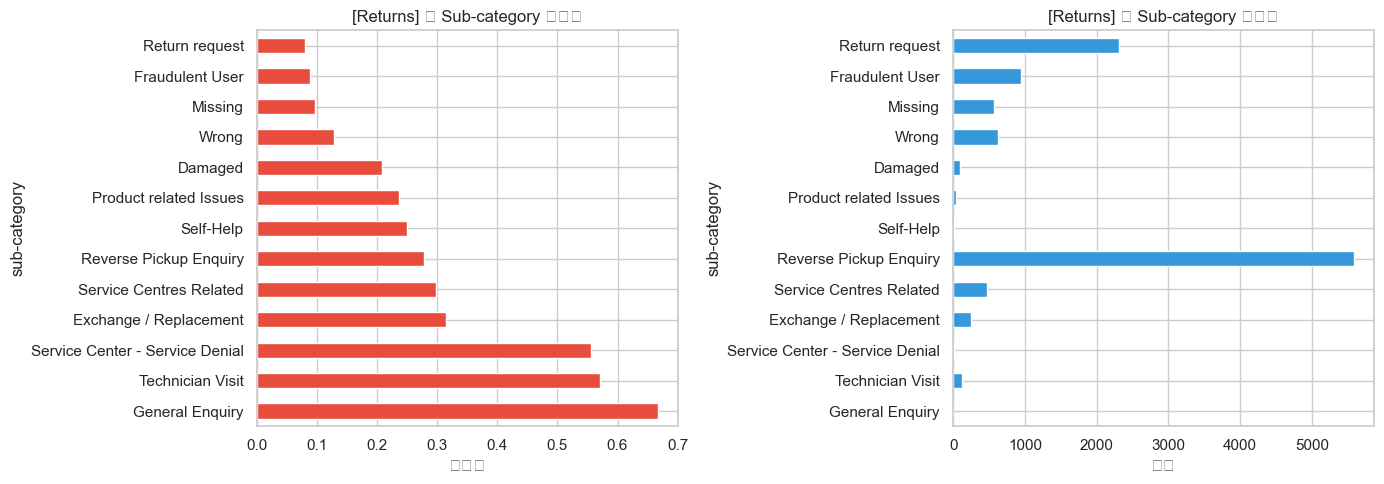

In [20]:
# 5.1 Returns 主题下的 Sub-category 差评率
returns_df = df_text[df_text['category'] == 'Returns'].copy()

sub_neg_rate = (
    returns_df.groupby('sub-category')['is_negative']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'neg_rate', 'sum': 'neg_count', 'count': 'total'})
    .sort_values('neg_rate', ascending=False)
)
print(f'=== [Returns] Sub-category 差评率 ===')
display(sub_neg_rate)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sub_neg_rate['neg_rate'].plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('[Returns] 各 Sub-category 差评率', fontsize=12)
axes[0].set_xlabel('差评率')

sub_neg_rate['total'].plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('[Returns] 各 Sub-category 客询量', fontsize=12)
axes[1].set_xlabel('数量')

plt.tight_layout()
plt.show()

---
## Step 6: 优先级评分模型

构建优先级评分: 差评量 × 差评率 × 涉及渠道数 → 综合优先级

In [21]:
# 6.1 各主题优先级评分
priority = (
    df_text.groupby('category')
    .agg(
        total=('is_negative', 'count'),
        neg_count=('is_negative', 'sum'),
        neg_rate=('is_negative', 'mean'),
        avg_csat=('csat_score', 'mean'),
        channel_count=('channel_name', 'nunique'),
    )
)

# 归一化各维度到 0-1
for col in ['neg_count', 'neg_rate', 'channel_count']:
    col_min = priority[col].min()
    col_max = priority[col].max()
    priority[f'{col}_norm'] = (priority[col] - col_min) / (col_max - col_min) if col_max > col_min else 0

# 综合优先级 = 差评量(0.4) + 差评率(0.4) + 渠道覆盖(0.2)
WEIGHT_NEG_COUNT = 0.4
WEIGHT_NEG_RATE = 0.4
WEIGHT_CHANNEL = 0.2

priority['priority_score'] = (
    priority['neg_count_norm'] * WEIGHT_NEG_COUNT +
    priority['neg_rate_norm'] * WEIGHT_NEG_RATE +
    priority['channel_count_norm'] * WEIGHT_CHANNEL
)
priority = priority.sort_values('priority_score', ascending=False)

display_cols = ['total', 'neg_count', 'neg_rate', 'avg_csat', 'channel_count', 'priority_score']
display(priority[display_cols].style.format({
    'neg_rate': '{:.1%}',
    'avg_csat': '{:.2f}',
    'priority_score': '{:.3f}'
}).background_gradient(subset=['priority_score'], cmap='Reds'))

,total,neg_count,neg_rate,avg_csat,channel_count,priority_score
category,,,,,,
Order Related,5831,1828,31.3%,3.62,3,0.754
Returns,11050,2294,20.8%,4.05,3,0.634
Cancellation,551,197,35.8%,3.46,3,0.553
Product Queries,1015,313,30.8%,3.58,3,0.479
App/website,16,5,31.2%,3.75,3,0.433
Others,35,14,40.0%,3.26,2,0.402
Feedback,607,162,26.7%,3.81,3,0.374
Offers & Cashback,117,32,27.4%,3.82,3,0.364
Refund Related,1097,267,24.3%,3.92,3,0.348


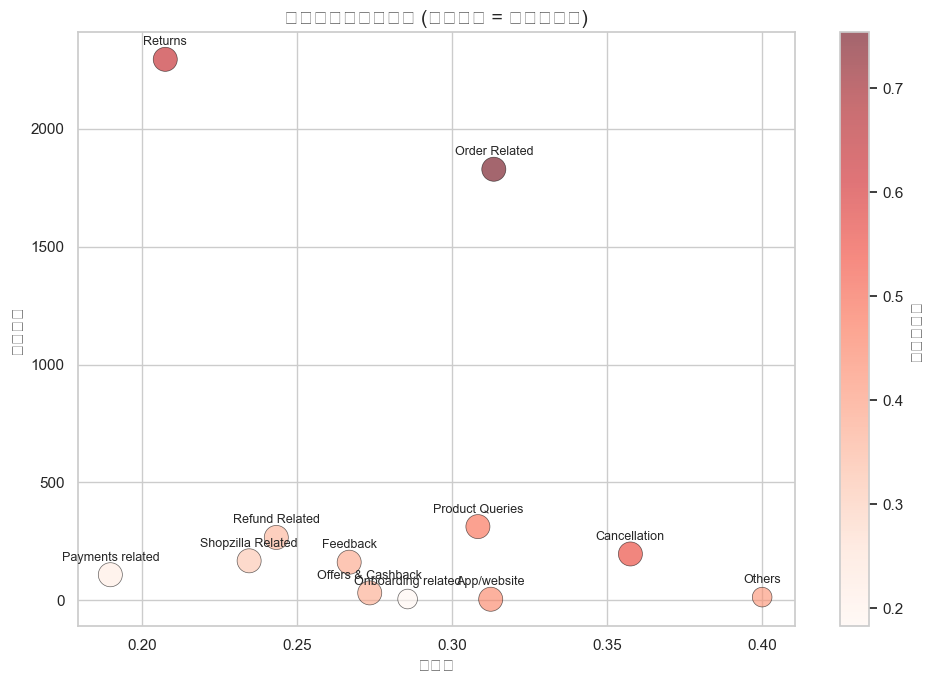

In [22]:
# 6.2 气泡图：差评率 × 差评量 × 渠道数
fig, ax = plt.subplots(figsize=(10, 7))

bubble_size = priority['channel_count'] * 100
scatter = ax.scatter(
    priority['neg_rate'],
    priority['neg_count'],
    s=bubble_size,
    alpha=0.6,
    c=priority['priority_score'],
    cmap='Reds',
    edgecolors='black',
    linewidth=0.5
)

for idx, row in priority.iterrows():
    ax.annotate(
        idx, (row['neg_rate'], row['neg_count']),
        fontsize=9, ha='center', va='bottom',
        xytext=(0, 8), textcoords='offset points'
    )

plt.colorbar(scatter, label='优先级评分')
ax.set_xlabel('差评率', fontsize=12)
ax.set_ylabel('差评数量', fontsize=12)
ax.set_title('痛点主题优先级矩阵 (气泡大小 = 涉及渠道数)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 📋 结论与建议

### 方法论总结
1. **不需要 LDA 盲猜主题**：当业务已有主题标签时，直接复用，避免无监督聚类的不可控性。
2. **全集统一 TF-IDF → 按标签 GroupBy**：保证 IDF 基准一致、词权重可横向比较。
3. **差评 - 好评 权重差**：提取差评独有痛点词，直接指导业务改进。

### 业务建议
基于优先级评分，建议优先解决排名靠前的主题下的高频痛点词所指向的问题。